In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    r"C:\Users\Admin\Documents\OnlineRetail_Cleaned.csv",
    dtype={"InvoiceNo": str},
    parse_dates=["InvoiceDate"]
)

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 524878 entries, 0 to 524877
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  str           
 1   StockCode    524878 non-null  str           
 2   Description  524878 non-null  str           
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[us]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   524878 non-null  int64         
 7   Country      524878 non-null  str           
 8   Revenue      524878 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 36.0 MB


In [6]:
df.shape

(524878, 9)

In [7]:
# Summary Statistics
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,524878.000000,524878,524878.000000,524878.000000,524878.000000
mean,10.616600,2011-07-04 15:30:16.317049,3.922573,11437.732164,20.275399
min,1.000000,2010-12-01 08:26:00,0.001000,0.000000,0.001000
25%,1.000000,2011-03-28 12:13:00,1.250000,0.000000,3.900000
50%,4.000000,2011-07-20 11:22:00,2.080000,14350.000000,9.920000
75%,11.000000,2011-10-19 11:41:00,4.130000,16245.000000,17.700000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,168469.600000
std,156.280031,NaN,36.093028,6799.513627,271.693566


In [8]:
# Top Selling Products
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

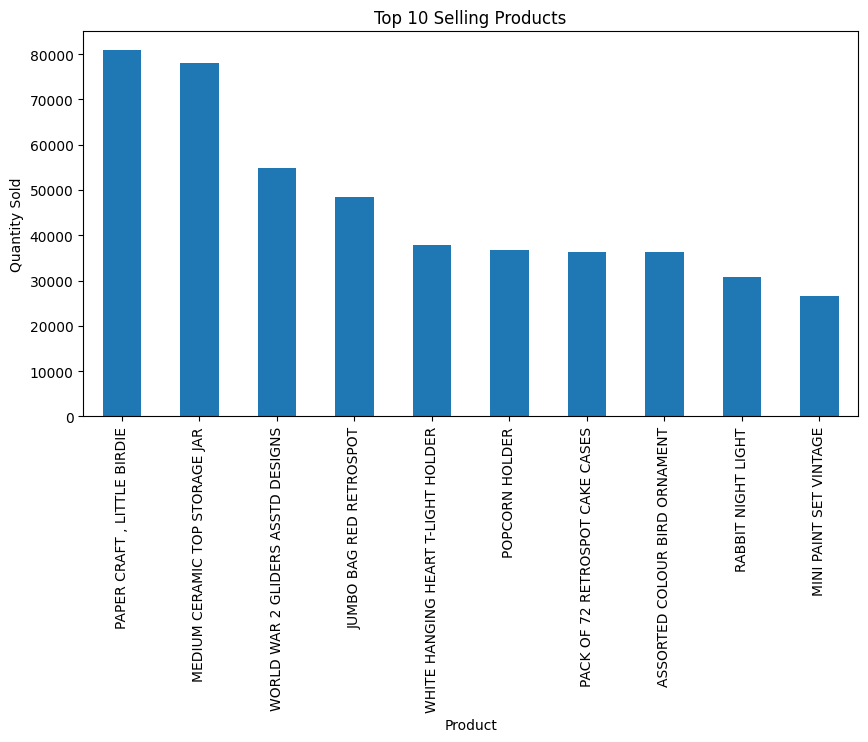

In [9]:
plt.figure(figsize=(10,5))
top_products.plot(kind="bar")
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=90)
plt.show()


### Findings
The bar chart shows the top 10 best-selling products based on the total quantity sold. The products with the highest bars were purchased more frequently than the others, indicating high customer demand. These products contribute significantly to the retailer's overall sales volume and may represent the company's most popular items.

In [10]:
# Revenue by Country
country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_sales

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

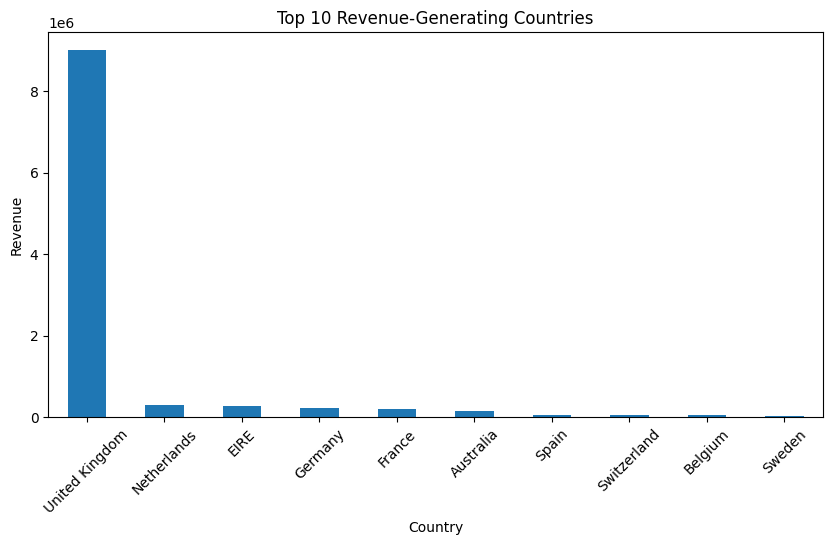

In [11]:
plt.figure(figsize=(10,5))
country_sales.plot(kind="bar")
plt.title("Top 10 Revenue-Generating Countries")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

### Findings
The chart shows that the United Kingdom generated the highest revenue by a large margin, making it the retailer's primary market. Other countries such as EIRE (Ireland), the Netherlands, Germany, and France contributed considerably less revenue. This indicates that the majority of the retailer's sales were concentrated within the United Kingdom.

In [12]:
# Monthly Sales Trend
df["Month"] = df["InvoiceDate"].dt.to_period("M")
monthly_sales = df.groupby("Month")["Revenue"].sum()

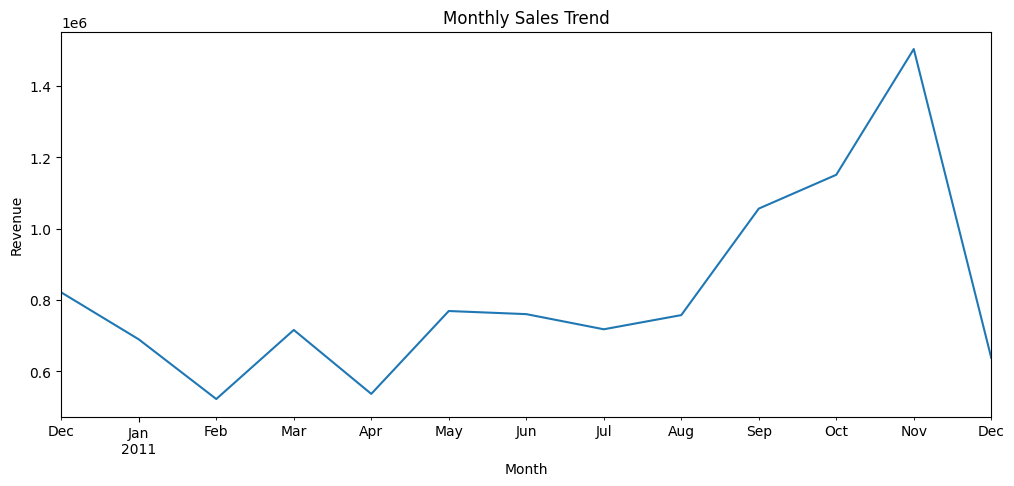

In [13]:
plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

### Findings
Monthly sales revenue generally increased over the year, with a noticeable peak towards the end of the year. This suggests increased customer purchasing activity during the holiday season.

In [14]:
# Top Customers
top_customers = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

CustomerID
0        1754901.91
14646     280206.02
18102     259657.30
17450     194390.79
16446     168472.50
14911     143711.17
12415     124914.53
14156     117210.08
17511      91062.38
16029      80850.84
Name: Revenue, dtype: float64

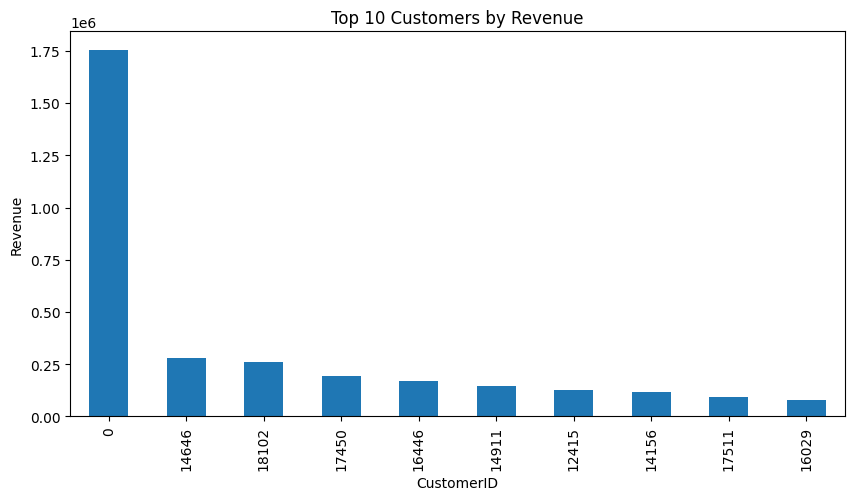

In [15]:
plt.figure(figsize=(10,5))
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Revenue")
plt.ylabel("Revenue")
plt.show()

### Findings
The chart identifies the top 10 customers based on total revenue generated. A small number of customers contributed a significant proportion of total sales, indicating that loyal or high-value customers play an important role in the retailer's business.

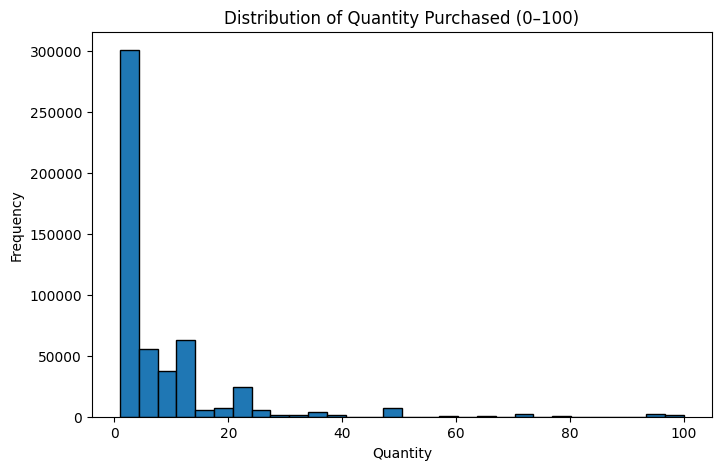

In [16]:
# Distribution Of Quantity
plt.figure(figsize=(8,5))
plt.hist(
    df[df["Quantity"] <= 100]["Quantity"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Quantity Purchased (0–100)")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

### Findings
The histogram shows that most transactions involved purchasing a small number of items, with the highest frequency occurring between one and five units. As the quantity purchased increased, the number of transactions decreased considerably. This indicates that small purchases were more common than bulk purchases.

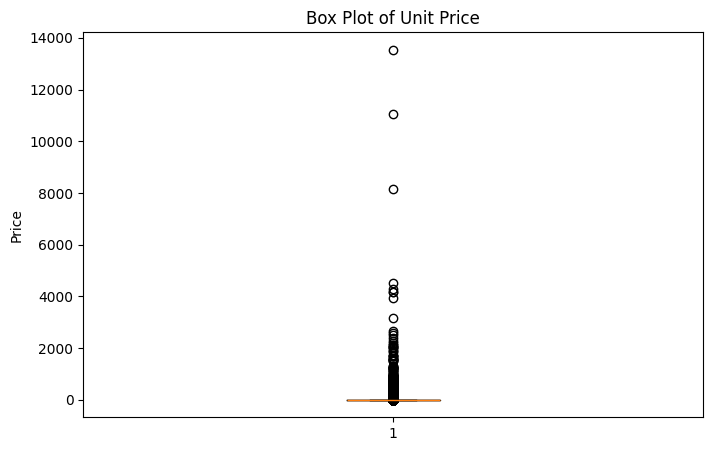

In [17]:
# Box Plot for Unit price
plt.figure(figsize=(8,5))
plt.boxplot(df["UnitPrice"])
plt.title("Box Plot of Unit Price")
plt.ylabel("Price")
plt.show()

### Findings
The box plot shows that most products were sold at relatively low prices, while several products had exceptionally high prices, appearing as outliers. This indicates that the unit price distribution is positively skewed, with only a few premium-priced products.

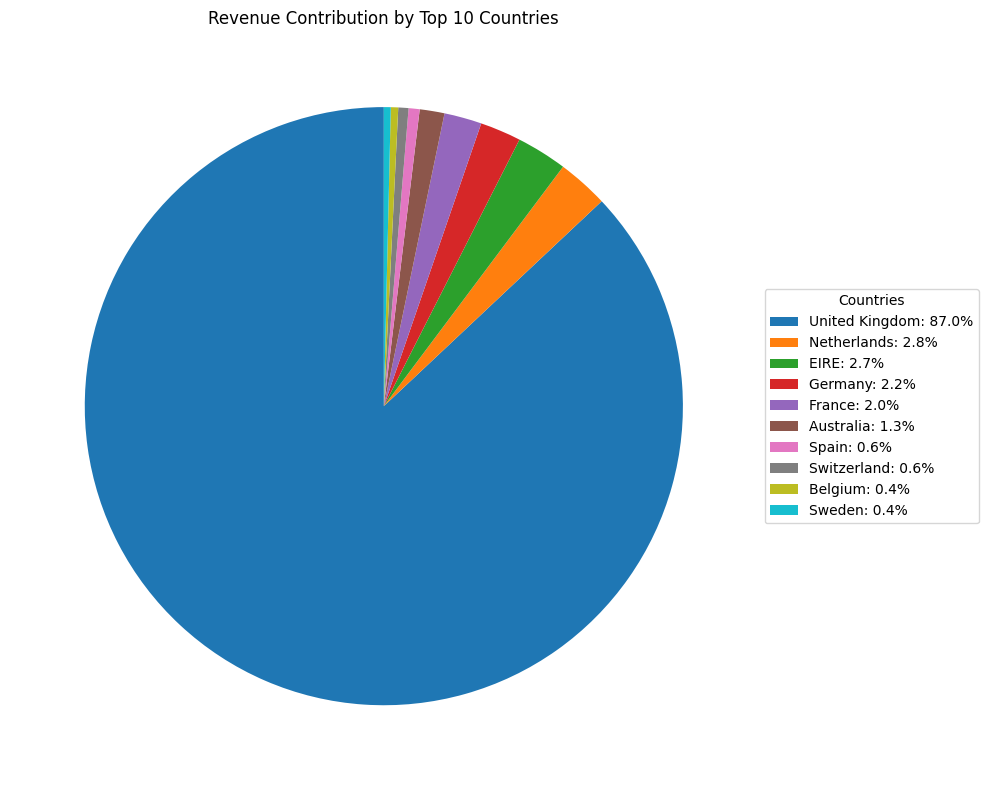

In [24]:
# Revenue Contribution by Top Countries
plt.figure(figsize=(10,8))

wedges, texts = plt.pie(
    country_sales.head(10),
    startangle=90
)

labels = [
    f"{country}: {value/sum(country_sales.head(10))*100:.1f}%"
    for country, value in country_sales.head(10).items()
]

plt.legend(
    wedges,
    labels,
    title="Countries",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Revenue Contribution by Top 10 Countries")
plt.tight_layout()

plt.show()

### Findings
The pie chart shows that the United Kingdom contributed approximately 87% of the revenue generated by the top 10 countries, making it the retailer's dominant market. The remaining countries each contributed only a small percentage of total revenue, indicating that international sales were considerably lower than domestic sales. This demonstrates that the retailer relied heavily on customers in the United Kingdom.